# Imports

In [64]:
import pandas as pd

# read csv

In [65]:
cancer_df = pd.read_csv("CANCER_TABLE.csv")

# Inspect data

In [66]:
cancer_df.head(5)

,diameter (cm),cancer
0,6.309685,False
1,4.580894,False
2,6.310071,False
3,7.495139,False
4,2.216181,False


In [67]:
cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   diameter (cm)  1000 non-null   float64
 1    cancer        1000 non-null   bool   
dtypes: bool(1), float64(1)
memory usage: 8.9 KB


In [68]:
for col in cancer_df.columns:
    print(repr(col))

'diameter (cm)'
' cancer'


THERE is a space in the name of cancer -_-

In [69]:
cancer_df.columns = cancer_df.columns.str.strip()

In [70]:
cancer_df["cancer"].value_counts()

cancer
False    807
True     193
Name: count, dtype: int64

In [71]:
cancer_df.rename(columns={"diameter (cm)": "diameter"}, inplace=True)

In [72]:
cancer_df.describe()

,diameter
count,1000.000000
mean,4.971051
std,2.934147
min,0.059294
25%,2.401131
50%,4.923567
75%,7.605594
max,9.994688


Lets create thier model

In [73]:
model = lambda diameter: 1 if diameter > 7 else 0

In [74]:
cancer_df["prediction"] = cancer_df.diameter.apply(model)

TP:

In [75]:
true_positive = cancer_df[
    (cancer_df.prediction == True) & 
    (cancer_df.cancer == True)].prediction.count()
true_positive

np.int64(193)

193 true positive
thats all of them! impressive
now lets do TN


TN

In [76]:
true_negative = cancer_df[
    (cancer_df.prediction == False) & 
    (cancer_df.cancer == False)].prediction.count()
true_negative

np.int64(689)

689 True Negative

FP

In [77]:
false_positive = cancer_df[
    (cancer_df.prediction == True) & 
    (cancer_df.cancer == False)].prediction.count()
false_positive

np.int64(118)

118 FP

FN

In [78]:
false_negative = cancer_df[
    (cancer_df.prediction == False) & 
    (cancer_df.cancer == True)].prediction.count()
false_negative

np.int64(0)

0 FN
means that when we guess someone doesnt have cancer he is forsure doesnt have cancer

now using all that lets calcualte some metrics

Recall / True Positive Rate

In [79]:
recall = true_positive / (false_negative + true_positive)
recall*100

np.float64(100.0)

sooooo out of all people who actually developed cancer (false_negative + true_positive) what percentage did we catch?
we caught all of them.

FPR (False Positive Rate)

In [80]:
false_positive_rate = false_positive / (false_positive + true_negative)
false_positive_rate*100

np.float64(14.622057001239158)

out of all the negative people (those who ddint have cancer) what percentage did we incorrectly flagged?
14.62% of people who did not develop cancer were incorrectly flagged as cancer-positive.

Precision

In [81]:
precision = true_positive / (true_positive + false_positive)
precision*100

np.float64(62.057877813504824)

Of everyone predicted to develop cancer, 62.06% actually developed cancer.

Accuracy

In [82]:
accuracy = (true_positive + 
            true_negative) / (true_positive + 
                              true_negative + 
                              false_positive + 
                              false_negative)
accuracy*100

np.float64(88.2)

what fraction of all predictions were correct
damn we are quite good (but the dataset aint that spread out there are too many non-cancer patients)

F1 Score

In [83]:
f1 = (2 * precision * recall) / (precision + recall)
f1*100

np.float64(76.5873015873016)

high balance between the recall and precision (although precision is limited by false positives...)

Part 2: Ranking Model

a ranking model predicts the output by ranking the probability of cancer on the patients and then decided find its decision by a threshold 

pitch to customer:
this is much better than the old model because first it includes it, if you choose the threshold matching the old model's output you get the same performance.
so this model is by definition at least as better as the old model
why is it better though? since now you can tune the threshold to your liking, if you want it more secured to never miss cancer or maybe you want it half-half and let it be the doctors tool to use when deciding
its yours to choose, also we will provide metrics to help you and visualize for you what each threshold will result in

creating th model
choose thresholds

In [84]:
cancer_df["diameter"].sort_values().unique()

array([0.0592936 , 0.06339614, 0.07016332, 0.07017431, 0.07038417,
       0.07319461, 0.08864834, 0.09246661, 0.10066565, 0.10071245,
       0.11007693, 0.11936158, 0.12940468, 0.13484914, 0.13832915,
       0.14051236, 0.14742598, 0.16095751, 0.16209815, 0.18847273,
       0.19244787, 0.19622281, 0.20628522, 0.20822125, 0.21298948,
       0.21769907, 0.24888879, 0.25917851, 0.2861715 , 0.2928881 ,
       0.29486865, 0.29699853, 0.29852905, 0.30331257, 0.31095417,
       0.31489194, 0.33049259, 0.34273748, 0.34961753, 0.35990433,
       0.36167551, 0.36348355, 0.36575297, 0.37736452, 0.40474342,
       0.41355265, 0.42123429, 0.42181222, 0.43527744, 0.44510314,
       0.46568394, 0.46994671, 0.47284007, 0.47415622, 0.47878249,
       0.48487394, 0.4968741 , 0.51332815, 0.52779518, 0.54193349,
       0.54346638, 0.55109825, 0.55156903, 0.56205899, 0.56341452,
       0.57559703, 0.59667599, 0.60540636, 0.61322015, 0.62711466,
       0.63247847, 0.64039399, 0.66394102, 0.69394021, 0.69738

In [85]:
import numpy as np

values = cancer_df["diameter"].sort_values().unique()

n = 600

quantiles = []
level = 1

while len(quantiles) < n:
    quantiles.extend(
        np.arange(1, 2**level, 2) / 2**level
    )
    level += 1

quantiles = quantiles[:n]

chosen = np.quantile(values, quantiles, method="nearest")

thresholds = chosen

In [86]:
metrics_df = pd.DataFrame(columns=["threshold"])
metrics_df['threshold'] = thresholds


In [87]:
def calculate_prediction(given_model, data_df: pd.DataFrame):
    data_df = data_df.copy()

    data_df["prediction"] = data_df.diameter.apply(given_model)

    return data_df

def calculate_tp_fp_tn_fn(data_df: pd.DataFrame):

    tp = data_df[
        (data_df.prediction == True) &
        (data_df.cancer == True)
    ].prediction.count()

    fp = data_df[
        (data_df.prediction == True) &
        (data_df.cancer == False)
    ].prediction.count()

    tn = data_df[
        (data_df.prediction == False) &
        (data_df.cancer == False)
    ].prediction.count()

    fn = data_df[
        (data_df.prediction == False) &
        (data_df.cancer == True)
    ].prediction.count()

    return tp, fp, tn, fn

def calculate_tpr_fpr(tp, fp, tn, fn):

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    return tpr, fpr

def calculate_acc_prec_recall(tp, fp, tn, fn):
    accuracy = (tp + 
            tn) / (tp + 
                              tn + 
                              fp + 
                              fn)
    precision = tp / (tp + fp)
    recall = tp / (fn + tp)
    return accuracy, precision, recall

def calc_metrics(metrics_df: pd.DataFrame):

    df = metrics_df.copy()

    for index in df.index:

        threshold = df.loc[index, "threshold"]

        model = lambda diam: 1 if diam > threshold else 0

        pred_df = calculate_prediction(model, cancer_df)

        tp, fp, tn, fn = calculate_tp_fp_tn_fn(pred_df)

        tpr, fpr = calculate_tpr_fpr(tp, fp, tn, fn)

        accuracy, precision, recall = calculate_acc_prec_recall(
            tp, fp, tn, fn
        )

        df.loc[index, "tp"] = tp
        df.loc[index, "fp"] = fp
        df.loc[index, "tn"] = tn
        df.loc[index, "fn"] = fn

        df.loc[index, "tpr"] = tpr
        df.loc[index, "fpr"] = fpr

        df.loc[index, "accuracy"] = accuracy
        df.loc[index, "precision"] = precision
        df.loc[index, "recall"] = recall

    return df


In [88]:
metrics_df = calc_metrics(metrics_df)

In [89]:
metrics_df.head(10)

,threshold,tp,fp,tn,fn,tpr,fpr,accuracy,precision,recall
0,4.929330,193.0,306.0,501.0,0.0,1.000000,0.379182,0.694,0.386774,1.000000
1,2.408455,193.0,556.0,251.0,0.0,1.000000,0.688971,0.444,0.257677,1.000000
2,7.604940,193.0,57.0,750.0,0.0,1.000000,0.070632,0.943,0.772000,1.000000
3,1.105880,193.0,681.0,126.0,0.0,1.000000,0.843866,0.319,0.220824,1.000000
4,3.744259,193.0,431.0,376.0,0.0,1.000000,0.534077,0.569,0.309295,1.000000
5,6.341737,193.0,182.0,625.0,0.0,1.000000,0.225527,0.818,0.514667,1.000000
6,8.764987,125.0,0.0,807.0,68.0,0.647668,0.000000,0.932,1.000000,0.647668
7,0.551569,193.0,744.0,63.0,0.0,1.000000,0.921933,0.256,0.205977,1.000000
8,1.706119,193.0,619.0,188.0,0.0,1.000000,0.767038,0.381,0.237685,1.000000
9,3.012261,193.0,494.0,313.0,0.0,1.000000,0.612144,0.506,0.280932,1.000000


In [90]:
metrics_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   threshold  600 non-null    float64
 1   tp         600 non-null    float64
 2   fp         600 non-null    float64
 3   tn         600 non-null    float64
 4   fn         600 non-null    float64
 5   tpr        600 non-null    float64
 6   fpr        600 non-null    float64
 7   accuracy   600 non-null    float64
 8   precision  600 non-null    float64
 9   recall     600 non-null    float64
dtypes: float64(10)
memory usage: 47.0 KB


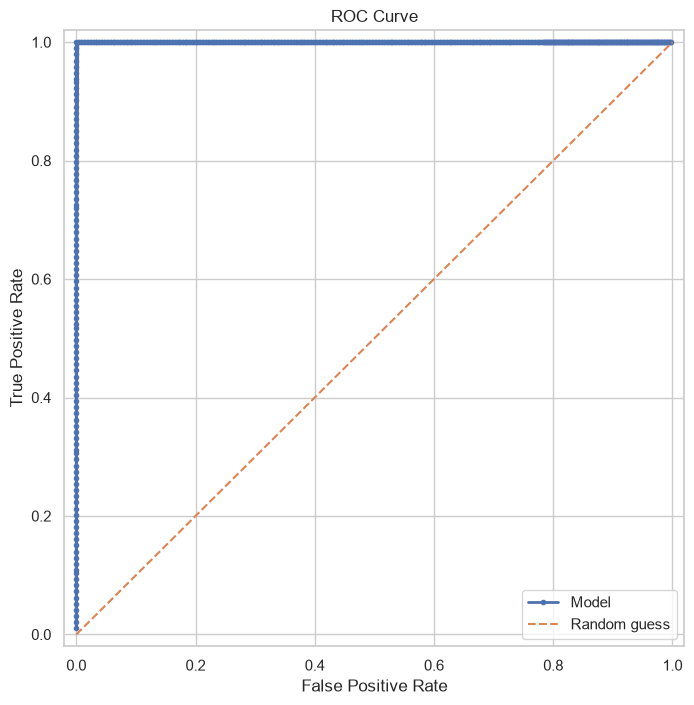

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
roc_df = metrics_df.sort_values("fpr")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 8))

plt.plot(
    roc_df["fpr"],
    roc_df["tpr"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)

plt.legend()
plt.show()

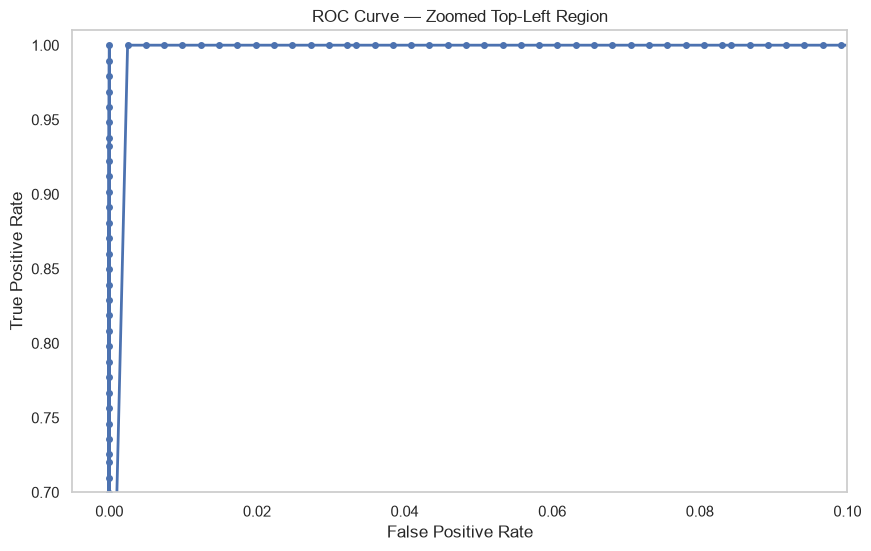

In [92]:
plt.figure(figsize=(10, 6))

plt.plot(
    roc_df["fpr"],
    roc_df["tpr"],
    marker="o",
    markersize=4,
    linewidth=2
)

plt.xlim(-0.005, 0.10)
plt.ylim(0.70, 1.01)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Zoomed Top-Left Region")

plt.grid()
plt.show()

In [93]:


endpoints = pd.DataFrame({
    "fpr": [0, 1],
    "tpr": [0, 1]
})

roc_df = pd.concat([
    roc_df[["fpr", "tpr"]],
    endpoints
])

roc_df = roc_df.sort_values("fpr")

auc = np.trapezoid(
    y=roc_df["tpr"],
    x=roc_df["fpr"]
)

auc

np.float64(1.0)

this auc is very good, almost ideal, it measures how good the underlying score/ranking is at separating positive from negatievs accross al possible thresholds

lets select a threshold first we want at least 95% recall, cuz its cancer...

In [95]:
candidates = metrics_df[
    metrics_df["tpr"] >= 0.95
]

best = candidates.sort_values(
    ["fpr", "tpr"],
    ascending=[True, False]
)

best.head(10)

,threshold,tp,fp,tn,fn,tpr,fpr,accuracy,precision,recall
461,7.981113,193.0,0.0,807.0,0.0,1.000000,0.000000,1.000,1.000000,1.000000
230,8.027551,191.0,0.0,807.0,2.0,0.989637,0.000000,0.998,1.000000,0.989637
462,8.051434,189.0,0.0,807.0,4.0,0.979275,0.000000,0.996,1.000000,0.979275
13,8.086143,187.0,0.0,807.0,6.0,0.968912,0.000000,0.994,1.000000,0.968912
463,8.110410,185.0,0.0,807.0,8.0,0.958549,0.000000,0.992,1.000000,0.958549
114,7.955587,193.0,2.0,805.0,0.0,1.000000,0.002478,0.998,0.989744,1.000000
460,7.935882,193.0,4.0,803.0,0.0,1.000000,0.004957,0.996,0.979695,1.000000
229,7.931644,193.0,6.0,801.0,0.0,1.000000,0.007435,0.994,0.969849,1.000000
459,7.912706,193.0,8.0,799.0,0.0,1.000000,0.009913,0.992,0.960199,1.000000
56,7.904556,193.0,10.0,797.0,0.0,1.000000,0.012392,0.990,0.950739,1.000000


ok so we should choose 7.98 threshold its the best 

In [97]:
best_th = best.iloc[0]
best_th

threshold      7.981113
tp           193.000000
fp             0.000000
tn           807.000000
fn             0.000000
tpr            1.000000
fpr            0.000000
accuracy       1.000000
precision      1.000000
recall         1.000000
Name: 461, dtype: float64

everything is ideal , so comparing to the before model is
kinda useless its better in every metrics

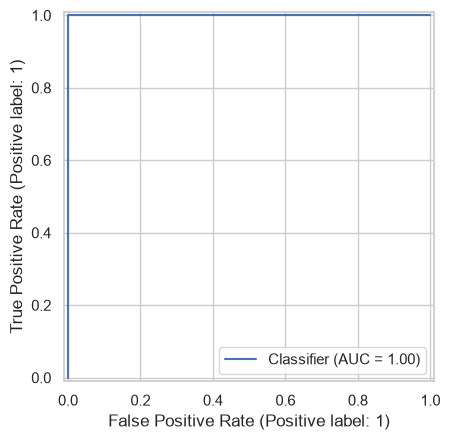

In [99]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    cancer_df["cancer"],
    cancer_df["diameter"]
)

plt.show()